# chap 2

목차
1. 결정 트리(decision tree)란?
2. 결정 트리 알고리즘
3. Variance(분산), Bias(편향)
4. Hyperparameter tuning for a decision tree
5. heart_disease 사례 연구

## 1. 결정 트리(decision tree)란?

XGBoost는 Ensemble method 중 하나이다. Ensemble method는 여러가지의 base learner(기본 학습기)로 이루어지는데 XGBoost의 Base learner로 Decision tree가 가장 널리 사용됨.

Decision tree는 train data가 모든 타깃에 정확하게 매핑될때까지 계속해서 분기할 수 있으므로 **overfitting(과대적합)**되기 쉬움.

overfitting을 방지하는 방법으로는 Decision tree에서는 Pruning, Stopping Rule이 있고, 

Random Forest와 XGBoost가 사용하는 여러개의 classifier를 모으는 방법이 있음


## 2. 결정 트리 알고리즘

Decision tree는 Branch 분할을 통해 두 개의 node로 나뉘고 최종 예측을 하는 leaf node까지 이어진다.

데이터셋 링크: https://github.com/rickiepark/handson-gb/tree/main/Chapter02

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
parent_path = Path.cwd().parents[2] # Path.cwd().parent.parent.parent하고 똑같음. parents는 리스트처럼 접근!
data_dir = parent_path / "04_Resources" / "Dataset" / "XGBoost"
df_census = pd.read_csv(data_dir / "census_cleaned.csv") # 챕터 1 회귀에서 한 거랑 똑같은거임

In [2]:
# 데이터 분할
y = df_census['income_ >50K']
X = df_census.drop('income_ >50K', axis=1)

# train set/test set 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=2 # test_size 지정 안하면 default값 0.25
)

# Decision Tree 모델링
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(random_state=2) # clf는 분류기(classifier)의 관례적 약자
clf.fit(X_train, y_train)
y_pred_clf = clf.predict(X_test)

# 정확도 accuracy 출력
acc = accuracy_score(y_test, y_pred_clf) # 샤갈 책에 오타나있음 무조건 정답 먼저(test), 그 다음에 예측값임(pred)
print(f"정확도: {acc:.2f}")              # accuracy_score는 test==pred 인지만 평가하기 때문에 순서 상관은 없지만
                                         # 다른 평가지표는 값이 달라질 수 있음

정확도: 0.81


분류 모델 평가에 사용되는 Confusion Matrix 개 중요함: https://youtu.be/yc-S2oju7G4?si=aAw01A6onw4oRmnR

**f1-score, recall(재현율), Precision(정밀도), 정분류율(Accuracy), TNR, TPR 공식을 알아두는게 좋음**

![혼돈 행렬 그림](confusion_matrix.png)

Decision Tree의 작동 원리는 무엇일까?

밑의 도식을 살펴보자

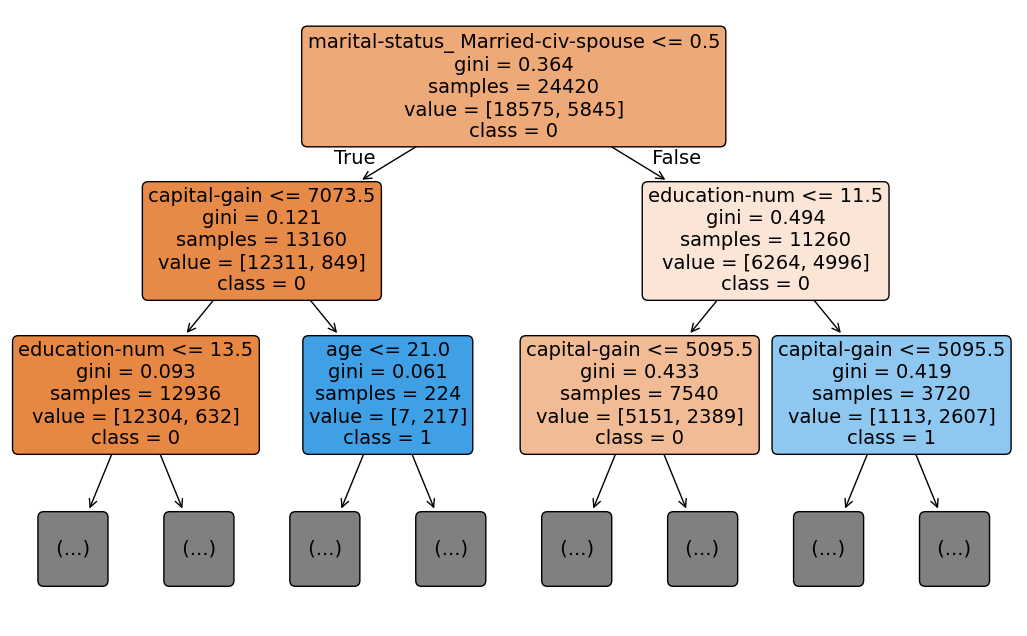

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(13,8))
plot_tree(clf, max_depth=2, feature_names=list(X.columns), class_names=['0', '1'],
          filled=True, rounded=True, fontsize=14)
plt.show()

1. Root node: 트리의 맨 위의 노드이다. marital-status(결혼 상태) Married-civ-spouse(시민 배우자와 결혼)은 원-핫 인코딩으로 이진 특성이므로 0(False) 1(True)로 구분 가능함. 첫 번째 분할은 결혼 유무를 기반으로 나눴다.
2. Gini impurity(지니 불순도): Root node의 두 번째 줄 Gini=0.364이다. 이 값을 gini impurity라고 함. 분할은 지니 불순도가 가장 낮은 분할을 찾는것이 목표이다.
$$G = 1 - \sum_{i=1}^{C} (p_i)^2$$
- $C$: 전체 클래스의 수
- $p_i$: 해당 구역에서 클래스 $i$가 차지하는 비율
3. sample: 해당 노드에 도달한 전체 데이터의 개수
4. value: 노드 안의 데이터들이 정답(클래스) 별로 몇 개씩 나뉘에 있는지. [12311, 849]는 class 0에 12311개 class 1에 849개 있다는 뜻
5. class: 최종 예측 클래스. 만약 분류가 이 노드에서 끝나면 최종적으로 어떤 정답으로 예측할 것인지. 맨 밑의 왼쪽 노드는 value가 class 0이 더 많기 때문에 최종 결정 시 0으로 예측
6. True/False 가지: 노드 맨 윗줄의 조건식으로 다음 노드로 분기
7. stump: 딱 한 번만 분할된 트리를 스텀프라고 함
8. Leaf node: 트리의 끝에 있는 노드를 리프 노드라고 함. 예를 들어 맨 밑의 왼쪽 노드는 12936개 샘플 중 12304개가 정확하게 예측된다. 따라서 미혼이고, capital gain이 7073.5 이하이면 소득이 5만 달러보다 적을 확률이 95%라고 볼 수 있다.

## 3. 분산과 편향

![회귀](linear.png)

훈련 데이터에 대해 학습을 해 새로운 데이터에 대한 예측을 만드는 방법은 선형 회귀 모델이 있다.

선형 회귀가 학습하는 방법을 알아보자

우리가 찾고자 하는 직선의 방정식은 다음과 같다고 가정하자..

$$\hat{y}_i = ax_i + b + e_i$$

여기서 실제 값 $y_i$와 예측 값 $\hat{y}_i$의 차이를 잔차(Residual) 라고 하며, $e_i = y_i - \hat{y}_i$ 로 표현한다.

우리의 목표는 잔차인 $e_i들의 제곱의 합인 잔차제곱합(RSS: Residual Sum of Square)을 최소화하는 $a$와 $b$를 찾는것이다

$$S(a, b) = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} (y_i - ax_i - b)^2$$

목적함수 $S(a, b)$를 $a$와 $b$로 각각 편미분 하고 그 결과가 0이 되는 방정식을 세우자

1. y절편 b에 대한 편미분
$$\frac{\partial S}{\partial b} = \sum_{i=1}^{n} 2(y_i - ax_i - b)(-1) = 0$$
2. 양 변을 -2로 나누고 정리하면
$$\sum_{i=1}^{n} y_i - a \sum_{i=1}^{n} x_i - \sum_{i=1}^{n} b = 0$$
3. $\sum_{i=1}^{n} b = nb$ 이므로.
$$nb = \sum_{i=1}^{n} y_i - a \sum_{i=1}^{n} x_i$$
4. 기울기 a에 대한 편미분
$$\frac{\partial S}{\partial a} = \sum_{i=1}^{n} 2(y_i - ax_i - b)(-x_i) = 0$$
5. 마찬가지로 양변을 -2로 나누고 $x_i$를 분배
$$\sum_{i=1}^{n} (x_i y_i - a x_i^2 - b x_i) = 0$$
6. 앞서 구한(3번) $b = \bar{y} - a\bar{x}$ 를 대입
$$\sum_{i=1}^{n} \left( x_i y_i - a x_i^2 - (\bar{y} - a\bar{x})x_i \right) = 0$$
7. 식의 괄호를 풀고 $a$가 있는 항과 없는 항으로 분리하여 정리합니다 ($\sum x_i = n\bar{x}$를 활용)
$$\sum_{i=1}^{n} x_i y_i - \bar{y}\sum_{i=1}^{n} x_i = a \sum_{i=1}^{n} x_i^2 - a\bar{x}\sum_{i=1}^{n} x_i$$
$$\sum_{i=1}^{n} x_i y_i - n\bar{x}\bar{y} = a \left( \sum_{i=1}^{n} x_i^2 - n\bar{x}^2 \right)$$
8. a에 대하여 정리
$$a = \frac{\sum_{i=1}^{n} x_i y_i - n\bar{x}\bar{y}}{\sum_{i=1}^{n} x_i^2 - n\bar{x}^2}$$
9. 이는 공분산과 분산의 개념을 이용해 친숙하게 표현 가능하다
$$a = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2} = \frac{Cov(x, y)}{Var(x)}$$
10. a를 구했으므로 b는  $b = \bar{y} - a\bar{x}$ 식에 대입하면 구할 수 있음

직선은 일반적으로 편향이 크다. (모델을 실제 문제에 적용할 때의 오차)

대부분의 경우 정확한 예측할 만큼 복잡하지 않으므로 이를 과소적합 되었다고 말한다.

하지만 위 그림의 오른쪽 회귀를 보면 train 데이터에 너무 fit하게 학습되어서 실제 데이터를 예측할 때 정확하지 않게 예측할 가능성이 높다.

이름 과대적합 되었다고 말한다.

과적합된 모델은 분산이 높다.

분산은 random variable(확률 변수)와 평균 사이의 차이를 제곱한 것이다.

분산이 높은 모델은 데이터에 과대적합되기 쉽다.

따라서 새로운 데이터에 잘 일반화되지 못한다

분산과 편향 사이의 균형을 잘 맞추기 위한 방법 중 하나는 **하이퍼파라미터 튜닝**이다.

## 4. Hyperparameter tuning for a decision tree

In [5]:
df_bikes = pd.read_csv(data_dir / "bike_rentals_cleaned.csv") # 데이터 로드
y_bikes = df_bikes['cnt'] # 타겟변수 분리
X_bikes = df_bikes.drop('cnt', axis=1)

from sklearn.model_selection import train_test_split # train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_bikes, y_bikes, random_state=2
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

In [8]:
reg = DecisionTreeRegressor()
scores = cross_val_score(reg, X_bikes, y_bikes, scoring='neg_root_mean_squared_error', cv=5)
rmse = -scores
print(f'RMSE 평균: {rmse.mean():.2f}')

RMSE 평균: 1193.00


rmse가 1193... chap1에서 얻은 선형 회귀 모델이나 XGboost 회귀 모델보다 안좋음

왜그럴까? 분산이 너무 높아서 과대적합 됐나?

In [10]:
reg = DecisionTreeRegressor()
reg.fit(X_train, y_train)
y_pred_ref = reg.predict(X_train) # 훈련값이 얼만큼 적합됐는지 확인

from sklearn.metrics import root_mean_squared_error
rmse_reg = root_mean_squared_error(y_train, y_pred_ref)
print(f"얼마나 train set에 적합됐을까?: {rmse_reg:.2f}")

얼마나 train set에 적합됐을까?: 0.00


샤갈! 0임 그 말은 훈련 데이터에 완전히 과대적합돼서 분산이 크다는 뜻임

훈련 데이터에서는 완벽한 성능이지만 실제 예측을 수행할때는 잘 일반화하지 못해버리는 문제가 발생했음.

In [11]:
# 참고) 리프 노드의 샘플 개수 확인
# DecisionTreeRegressor의 max_depth 옵션은 기본값이 None임. 따라서 모든 노드가 pure node가 될 때 까지 성장함. -> 과적합
# reg 객체의 tree_ 속성(피처)에는 훈련된 트리 객체 저장
# node_count 속성에는 트리 전체 노드 개수 저장
# n_node_samples 속성에는 각 노드에 포함된 샘플 개수 저장
# children_left, children_right 속성에는 자식 노드의 인덱스가 저장되어있다. 이 두 속성이 -1이면 leaf node이다

leaf_node_count = 0
tree = reg.tree_
for i in range(tree.node_count): # 전체 노드 개수 만큼 반복
    if(tree.children_left[i] == -1) and (tree.children_right[i] == -1):
        leaf_node_count += 1
        if tree.n_node_samples[i] > 1:
            print(f'노드 인덱스: {i}', f'샘플 개수: {tree.n_node_samples[i]}')

print(f'전체 leaf node 개수: {leaf_node_count}')

노드 인덱스: 124 샘플 개수: 2
전체 leaf node 개수: 547


train dataset 크기가 548인데 leaf node 개수가 547개면 너무 과적합됐다고 판단된다.

왜인지 모르겠으면 제미나이한테 물어보셈 ㅉㅉ

그러면 더 나은 모델을 위한 하이퍼파라미터들을 알아보자

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor

공식 문서 가면 나오긴 하는데 이해하기 힘들잖어~

### 1. max_depth

In [14]:
reg = DecisionTreeRegressor(max_depth=4, random_state=2) # 트리의 분할 횟수(깊이)를 설정해 과대적합을 방지
reg.fit(X_train, y_train)
y_pred_reg = reg.predict(X_test)
print(f"rmse: {root_mean_squared_error(y_test, y_pred_reg):.2f}")

rmse: 865.82


분할 횟수를 4번으로 줄이기만 했는데 1193 -> 865으로 성능이 개선됐다.

그렇다면 어떻게 최적에 가까운 max_depth를 구할 수 있을까?

수를 하나씩 대입하는건 힘들다.

### 2. GridSearchCV

GridSearchCV 클래스는 fit()으로 전달한 데이터를 통해 k-fold 교차 검증을 수행한다.

- refit 매개변수는 기본값 True로 fit()을 완료하면 다음 속성을 뽑을 수 있다
- best_params_: 찾은 최적의 하이퍼파라미터 조합 딕셔너리
- best_score_: 최적의 파라미터일 때 교차 검증 최고 점수
- best_estimator_: 최적의 파라미터로 '전체 훈련 데이터'를 사용해 재학습이 완료된 최종 모델 객체 (가장 중요)


- njobs 매개변수는 기본값 1로 몇 개의 CPU프로세서를 사용할 것인지 정한다. -1로 설정하면 모든 프로세서 사용.

그리드 서치는 cross-validation을 통해 최선의 조합을 갖는 매개변수 조합을 탐색한다.

In [15]:
from sklearn.model_selection import GridSearchCV
params = {'max_depth': [None, 2, 3, 4, 5, 6, 8, 10, 20]}

reg = DecisionTreeRegressor(random_state=2)
grid_reg = GridSearchCV(reg, params, scoring='neg_root_mean_squared_error',
                        cv=5, return_train_score=True, n_jobs=-1)
grid_reg.fit(X_train, y_train)
best_params = grid_reg.best_params_
print(f"최적의 매개변수: {best_params}")

최적의 매개변수: {'max_depth': 6}


In [19]:
best_score = -grid_reg.best_score_
print(f"훈련 점수: {best_score:.2f}")

훈련 점수: 945.05


In [21]:
best_model = grid_reg.best_estimator_
y_pred = best_model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, y_pred)
print(f"테스트 점수: {rmse_test:.2f}")

테스트 점수: 864.67


In [22]:
# 그리드 서치를 수행하는 함수를 만들어놓자
def grid_search(params, reg=DecisionTreeRegressor(random_state=2)):
    grid_reg = GridSearchCV(reg, params, scoring='neg_root_mean_squared_error',
                        cv=5, return_train_score=True, n_jobs=-1)
    grid_reg.fit(X_train, y_train)
    best_params = grid_reg.best_params_
    print(f"최적의 매개변수: {best_params}")
    best_score = -grid_reg.best_score_
    print(f"훈련 점수: {best_score:.2f}")
    best_model = grid_reg.best_estimator_
    y_pred = best_model.predict(X_test)
    rmse_test = root_mean_squared_error(y_test, y_pred)
    print(f"테스트 점수: {rmse_test:.2f}")

### 3. min_samples_leaf

리프 노드가 가질 수 있는 최소 샘플의 개수 제한.

기본값은 1이므로 계속해서 분할할 수 있다.

In [23]:
# 범위를 정하기 전에 훈련 세트의 크기을 알아보자
X_train.shape

(548, 12)

548개의 데이터가 있네. 그러면 1 ~ 30 사이의 값으로 진행해볼까?

In [24]:
grid_search(params={'min_samples_leaf': [1,2,4,6,8,10,20,30]})

최적의 매개변수: {'min_samples_leaf': 8}
훈련 점수: 893.77
테스트 점수: 855.62


테스트 점수가 올랐다.

그러면 min_samples_leaf와 max_depth를 같이 시도해보자

In [25]:
grid_search(params={'min_samples_leaf': [1,2,4,6,8,10,20,30],
                    'max_depth': [None, 2, 3, 4, 5, 6, 8, 10, 20]})

최적의 매개변수: {'max_depth': 6, 'min_samples_leaf': 2}
훈련 점수: 869.67
테스트 점수: 913.00


훈련 점수는 좋아졌는데 테스트 점수는 오히려 나빠짐.

max_depth는 그대로인데 min_samples_leaf는 줄어듬.

교훈: 하이퍼파라미터는 개별적으로 선택하면 안된다.

In [27]:
# 분산을 줄이듯 min_samples_leaf를 3보다 크게 해보자
grid_search(params={'min_samples_leaf': [3,5,7,9],
                    'max_depth': [6,7,8,9]})

최적의 매개변수: {'max_depth': 9, 'min_samples_leaf': 7}
훈련 점수: 887.35
테스트 점수: 878.54


최종 결론: min_samples_leaf 하나만 사용해서 유연한 규제를 하는게 모델의 성능에 더 좋은 영향을 줬다.

cf. 위의 코드에서는 test 데이터를 통해 하이퍼파라미터 튜닝을 시행했지만 좋지 않은 방법이다.

데이터를 train valid test로 나누고 valid 데이터를 이용해 튜닝을 진행한 후 test 데이터로 성능 평가를 진행하는 것이 일반적이다.

### 4. max_leaf_nodes

leaf node의 전체 개수 설정. 기본값은 None 제한 없음

### 5. max_features

분할마다 모든 특성을 고려하는게 아니라 지정된 개수의 특성만 사용해 분할한다

따라서 분산을 줄이는데 도움을 준다

- None(기본값): 전체 특성 사용
- 'sqrt': 전체 특성 개수의 제곱근
- 'log2': 전체 특성 개수의 로그를 사용한다. 예를들어 16개의 특성이면 $log_2 16 = 4$개 사용

### 6. min_samples_split

분할할 수 있는 샘플의 최솟값. 기본값은 2이므로 2개보다 적은 샘플을 가진 노드는 분할하지 않음

### 7. splitter

- 'best': criterion 매개변수에 저장된 지표를 가장 크게 줄이는 방법으로 분할
- 'random': 랜덤하게 노드를 분할. 과대적합을 막고 다양한 트리 생성 가능

### 8. criterion

분할마다 지정한 함수를 계산하여 비교

1. 회귀모델의 경우
- 'squared_error' (기본값)
- 'friedman_mse'
- 'absolute_error'
- 'poisson'

2. 분류모델의 경우
- 'gini' (기본값)
- 'entropy'

### 9. min_impurity_decrease

기본값은 0으로 분할을 하기 위한 최소 불순도 감소량 지정

### 10. min_weight_fraction_leaf

트리가 성장해서 leaf node를 만들 때 이 입사귀의 데이터의 개수가 전체 데이터의 몇% 이상 되어야 그대로 두겠다는 규제 장치

예를들어 총 데이터가 1000개일 때 매개변수를 0.05로 설정하면 leaf node가 데이터를 최소 50개 이상 가지고 있어야만 생성이 된다.

### 11. ccp_alpha

최소 비용-복잡도 가지치기를 수행할 때 사용한다

$$R_{\alpha}(T) = R(T) + \alpha |T|$$
- $R_{\alpha}(T)$: 트리의 총 비용 (Cost)
- $R(T)$: 트리의 총 오차 또는 불순도 (예: 오분류율, MSE)
- $|T|$: 트리의 말단 노드(Leaf node)의 개수 (트리의 복잡도)
- $\alpha$ (ccp_alpha): 복잡도에 대한 페널티 가중치

쉽게 말해서 노드가 많아질수록(트리가 복잡) 페널티($\alpha |T|$)를 부여하여 오차를 조금 줄이는것 보다 구조를 단순하게 만드는 것이 낫다고 판단되면 가지를 자르는것임

ccp_alpha의 기본값은 0이므로 가지치기를 전혀 안함.

ccp_alpha값이 커지면 패널티가 더 커지므로 가지치기를 해서 트리 크기가 줄어듬

- 제미나이 펌:
언제, 어떻게 사용하나요? min_samples_leaf만으로 제어했을 때 좋은 성능을 얻으셨던 것처럼, 트리 기반 모델은 적절한 규제가 필수적입니다. ccp_alpha는 수학적으로 최적의 서브트리(Subtree)를 찾아내는 매우 세련된 방식이므로, 복잡한 데이터셋에서 과적합을 방지하는 데 탁월한 효과를 보입니다.최적의 ccp_alpha를 찾는 방법일반적으로 GridSearchCV에 무작위 값을 넣기보다는, 사이킷런(scikit-learn)에서 제공하는 cost_complexity_pruning_path 함수를 사용하여 **현재 데이터셋에서 의미 있는 가지치기가 일어나는 $\alpha$ 값들의 목록(Effective alphas)**을 먼저 추출합니다. 그런 다음 이 추출된 값들을 대상으로 교차 검증을 수행하여 최적의 값을 찾습니다.

## 5. heart_disease 사례 연구

In [28]:
df_heart = pd.read_csv(data_dir / "heart_disease.csv")
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


- age: 나이 (연령)
- sex: 성별 (1 = 남성, 0 = 여성)
- cp: 가슴 통증(협심증)의 유형 (1 = 전형적인 협심증, 2 = 비전형적인 협심증, 3 = 협심증이 아닌 통증, 4 = 무증상)
- trestbps: 병원 입원 시 안정 상태의 혈압 (단위: mm Hg)
- chol: 혈청 콜레스테롤 수치 (단위: mg/dl)
- fbs: 공복 혈당 수치가 120 mg/dl 초과 여부 (1 = 초과함, 0 = 이하)
- restecg: 안정 시 심전도 검사 결과 (0 = 정상, 1 = ST-T파 이상, 2 = 좌심실 비대 소견)
- thalach: 달성한 최대 심박수
- exang: 운동 유발성 협심증 여부 (1 = 발생함, 0 = 발생하지 않음)
- oldpeak: 휴식 상태와 비교하여 운동으로 유발된 ST 분절 강하 수치
- slope: 최대 운동 시 심전도 ST 분절의 기울기 (1 = 위로 상승함, 2 = 평탄함, 3 = 아래로 하강함)
- ca: 형광 투시경 검사로 확인된 주요 혈관의 수 (0~3 사이의 값)
- thal: 탈륨 심근 스캔 검사 결과 (3 = 정상, 6 = 고정 결손, 7 = 가역적 결손)
- target: 심장 질환 진단 결과이자 예측 대상 (0 = 질환 없음, 1~4 = 질환 있음)

In [30]:
# 이미 전처리를 해둔 데이터 셋이므로 바로 모델링을 해주자
y = df_heart['target']
X = df_heart.drop('target', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=2
)

분류 문제 이므로 DecisionTreeClassifier 모델을 이용하자

In [40]:
# 베이스라인 모델 생성
model = DecisionTreeClassifier(random_state=2)
scores = cross_val_score(model, X, y, cv=5)
print(f'정확도: {np.round(scores, 2)}')
print(f'정확도 평균: {np.mean(scores):.3f}')

정확도: [0.74 0.85 0.77 0.73 0.7 ]
정확도 평균: 0.759


초기 모델을 이용해 76% 정확도를 얻었다. 하이퍼파라미터 튜닝을 통해 성능 개선을 해보자.

In [38]:
from sklearn.model_selection import RandomizedSearchCV # 그리드 서치랑 같은 방식으로 작동 but, 랜덤한 조합으로 계산
def randomized_search_clf(params, runs=20, clf=DecisionTreeClassifier(random_state=2)):
    rand_clf = RandomizedSearchCV(clf, params, n_iter=runs,
                                  cv=5, n_jobs=-1, random_state=2)
    rand_clf.fit(X_train, y_train)
    best_model = rand_clf.best_estimator_
    y_pred_clf = best_model.predict(X_test)
    best_score = rand_clf.best_score_
    best_params = rand_clf.best_params_
    accuracy = accuracy_score(y_test, y_pred_clf)
    print(f'최적 파라미터: {best_params}')
    print(f'훈련 점수: {best_score:.3f}')
    print(f'테스트 점수: {accuracy:.3f}')
    return best_model


randomized_search_clf(params={
        'criterion':['entropy', 'gini'],
        'splitter':['random', 'best'],
        'min_samples_split':[2, 3, 4, 5, 6, 8, 10],
        'min_samples_leaf':[1, 0.01, 0.02, 0.03, 0.04],
        'min_impurity_decrease':[0.0, 0.0005, 0.005, 0.05, 0.10, 0.15, 0.2],
        'max_leaf_nodes':[10, 15, 20, 25, 30, 35, 40, 45, 50, None],
        'max_features':['sqrt', 0.95, 0.90, 0.85, 0.80, 0.75, 0.70],
        'max_depth':[None, 2,4,6,8],
        'min_weight_fraction_leaf':[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.05]
})

최적 파라미터: {'splitter': 'best', 'min_weight_fraction_leaf': 0.05, 'min_samples_split': 10, 'min_samples_leaf': 0.04, 'min_impurity_decrease': 0.0, 'max_leaf_nodes': 45, 'max_features': 0.8, 'max_depth': 8, 'criterion': 'entropy'}
훈련 점수: 0.798
테스트 점수: 0.855


DecisionTreeClassifier(criterion='entropy', max_depth=8, max_features=0.8,
                       max_leaf_nodes=45, min_samples_leaf=0.04,
                       min_samples_split=10, min_weight_fraction_leaf=0.05,
                       random_state=2)

위의 모델에서 얻은 max_depth=8을 기준으로 탐색 범위를 줄이면 성능을 향상시킬 수 있다.

그리고 기본값이 잘 작동하는 매개변수는 탐색에서 제외시키는 것도 좋은 전략이다

In [59]:
best_model = randomized_search_clf(  # criterion, splitter, min_impurity_decrease 삭제
    params={'max_depth':[None, 7, 8, 9],          # max_depth 탐색 범위 줄임
            'max_features':['sqrt', 0.78],
            'max_leaf_nodes':[45, None],
            'min_samples_leaf':[1, 0.035, 0.04, 0.045, 0.05],
            'min_samples_split':[2, 9, 10],
            'min_weight_fraction_leaf': [0.0, 0.05, 0.06, 0.07],
            },
    runs=100) # 더 많은 시행 횟수

최적 파라미터: {'min_weight_fraction_leaf': 0.06, 'min_samples_split': 10, 'min_samples_leaf': 0.05, 'max_leaf_nodes': 45, 'max_features': 0.78, 'max_depth': 9}
훈련 점수: 0.802
테스트 점수: 0.868


테스트 점수가 살짝 더 올랐다.

이제 best_model을 교차검증해 baseline모델과 비교해보자

In [60]:
scores = cross_val_score(best_model, X, y, cv=5)
print(f'정확도: {np.round(scores, 2)}')
print(f'정확도 평균: {np.mean(scores):.3f}')

정확도: [0.82 0.9  0.8  0.8  0.78]
정확도 평균: 0.822


0.759 -> 0.822로 약 6% 정확도가 향상됐다.

사이파이의 randint, uniform을 사용해 더 좋은 매개변수를 탐색해보자

In [58]:
from scipy.stats import loguniform, randint

params = {'max_depth': randint(8,11),
          'max_leaf_nodes': randint(44,47), # 2 이상이어야됨
          'max_features': loguniform(75e-2,80e-2),
          'min_samples_split': loguniform(3e-2,7e-2),
          'min_samples_leaf': loguniform(3e-2,7e-2),
          'min_weight_fraction_leaf': loguniform(5e-2,7e-2)}

best_model_2 = randomized_search_clf(params=params, runs=100)
scores = cross_val_score(best_model_2, X, y, cv=5)
print(f'정확도: {np.round(scores, 2)}')
print(f'정확도 평균: {np.mean(scores):.3f}')

최적 파라미터: {'max_depth': 8, 'max_features': np.float64(0.7923362341310985), 'max_leaf_nodes': 45, 'min_samples_leaf': np.float64(0.0361779075587264), 'min_samples_split': np.float64(0.056476045581050585), 'min_weight_fraction_leaf': np.float64(0.057813567742739186)}
훈련 점수: 0.802
테스트 점수: 0.868
정확도: [0.8  0.9  0.8  0.8  0.78]
정확도 평균: 0.818


특성 중요도 (feature importance)에 대해 알아보자

분류 모델은 어떤 feature가 중요한지 알려주는 feature_importances_ 속성이 있음

In [61]:
# 최종 모델은 전체 데이터 세트를 사용해 훈련
best_model.fit(X, y)
best_model.feature_importances_

array([0.04826754, 0.04081653, 0.48409586, 0.00568635, 0.        ,
       0.        , 0.        , 0.00859483, 0.        , 0.02690379,
       0.        , 0.18069065, 0.20494446])

In [74]:
importance_df = pd.DataFrame({'importance':best_model.feature_importances_}, index=X.columns)
importance_df['importance'].sort_values(ascending=False)

cp          0.484096
thal        0.204944
ca          0.180691
age         0.048268
sex         0.040817
oldpeak     0.026904
thalach     0.008595
trestbps    0.005686
chol        0.000000
exang       0.000000
restecg     0.000000
fbs         0.000000
slope       0.000000
Name: importance, dtype: float64

cp, thal, ca .. 순으로 의사결정에 높은 영향을 끼친다

하지만 feature_importance에는 연속형 수치에 유리하게 작용하는 단점이 있다.

permutation_importance는 특정 열의 값을 무작위로 섞어서 성능이 하락하는 폭을 측정한다.

이는 모든 모델에 적용 가능하고 과적합 판독, 연속형 변수 유리함 제거 등의 이점이 있으므로 실무에서 권장된다.

단 다중공선성 문제가 있을 경우에는 수치가 매우 낮게 나올 수 있으므로 주의가 필요.

In [73]:
from sklearn.inspection import permutation_importance

# 1. Permutation Importance 계산
# 주의: X_test, y_test (검증용 데이터)를 사용하는 것이 가장 이상적
# n_repeats=10: 각 변수를 10번씩 섞어보고 평균을 냄
result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# 2. 결과를 보기 쉽게 데이터프레임으로 정리
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean, # 섞었을 때 성능이 떨어진 평균 수치
    'Importance_Std': result.importances_std    # 10번 섞었을 때의 편차
})

# 3. 중요도(평균)가 높은 순으로 정렬
perm_df = perm_df.sort_values(by='Importance_Mean', ascending=False)

# 결과 출력
perm_df

,Feature,Importance_Mean,Importance_Std
12,thal,0.146053,0.033000
2,cp,0.109211,0.039055
9,oldpeak,0.047368,0.021379
11,ca,0.039474,0.030576
0,age,0.000000,0.000000
4,chol,0.000000,0.000000
3,trestbps,0.000000,0.000000
1,sex,0.000000,0.000000
5,fbs,0.000000,0.000000
8,exang,0.000000,0.000000


모델은 단 4가지의 변수로만 심장 질환 여부를 판단하고 있음을 알 수 있다.

보기 좋게 시각화 연습을 해보자

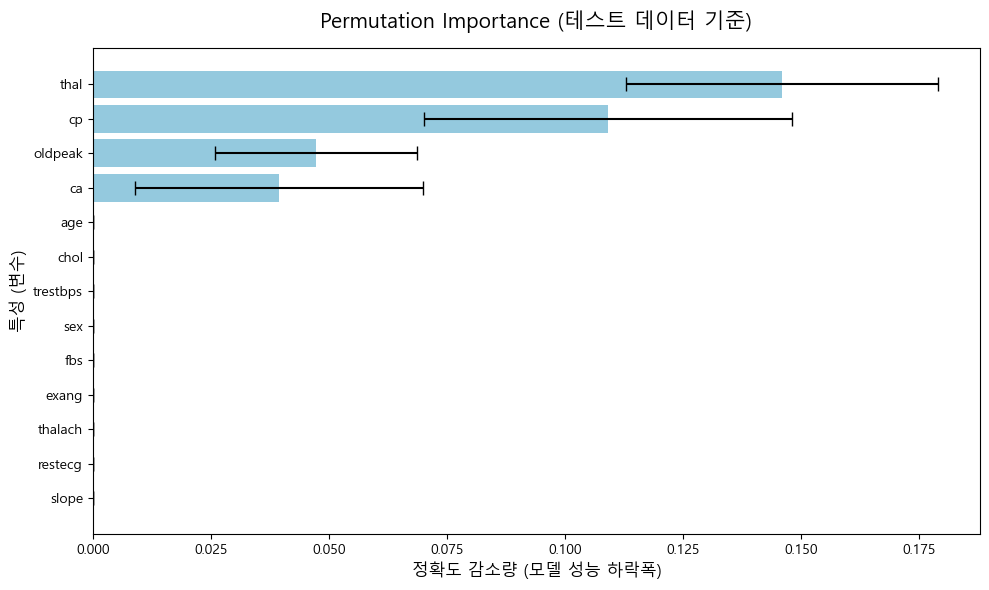

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 환경
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Mean', y='Feature', data=perm_df, color='skyblue')
plt.errorbar(x=perm_df['Importance_Mean'], y=range(len(perm_df)), 
             xerr=perm_df['Importance_Std'], fmt='none', c='black', capsize=5)

plt.title('Permutation Importance (테스트 데이터 기준)', fontsize=15, pad=15)
plt.xlabel('정확도 감소량 (모델 성능 하락폭)', fontsize=12)
plt.ylabel('특성 (변수)', fontsize=12)
plt.tight_layout()
plt.show()